# L3: Prefix Caching with RadixAttention

In L2, you built KV cache — Keys and Values stored so the model never recomputes them during generation. O(n²) dropped to O(n). But that cache lives and dies with a single request. The moment it finishes, the cache is thrown away.

Now think about production: a RAG app has the same document in front of every question, a chatbot has the same system prompt for every user. Each request independently computes identical KV tensors for those shared tokens. That's the waste we eliminate here.

<table style="width: 100%; border-collapse: collapse; margin: 20px 0;">
<thead style="background-color: #f5f5f5;">
<tr>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left; width: 80px;"></th>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Shared prefix (document / system prompt)</th>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left; width: 120px;">Unique suffix</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>Request 1</b></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #fff5f5;">
<span style="color: #c62828;">compute KV from scratch 😱</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd;">question 1</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>Request 2</b></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #fff5f5;">
<span style="color: #c62828;">compute KV from scratch 😱</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd;">question 2</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>Request 3</b></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #fff5f5;">
<span style="color: #c62828;">compute KV from scratch 😱</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd;">question 3</td>
</tr>
</tbody>
</table>
<p style="font-size: 13px; color: #666;">Identical KV tensors computed and discarded on every request — that's the waste prefix caching eliminates.</p>

## 📋 Learning Objectives

1. **Understand the waste** — Quantify how much redundant prefill work happens without prefix caching
2. **Implement RadixAttention** — See the four-step pattern: traverse, reuse, compute, store
3. **Measure the speedup** — Run three experiments: no cache, single-article cache, mixed workload
4. **Connect the arc** — See how L2's KV cache and L3's prefix caching compose into a complete optimization stack

## 1. The Speedup from Prefix Caching

<table style="width: 100%; border-collapse: collapse; margin: 20px 0;">
<thead style="background-color: #f5f5f5;">
<tr>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left; width: 120px;">Scenario</th>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Tokens to compute</th>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Loaded from cache</th>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left; width: 120px;">Prefill speedup</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>No caching</b></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #fff5f5;">
<span style="color: #c62828;">100% 😱</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd;">0%</td>
<td style="padding: 10px; border: 1px solid #ddd;">1×</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>This notebook</b><br><span style="font-size: 12px; color: #666;">short articles</span></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #fff5f5;">
<span style="color: #c62828;">~50% 😱</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #f0f9f0;">
<span style="color: #2e7d32;">~50% ✨</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #f0f9f0;"><b style="color: #2e7d32;">~2×</b></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>Production</b><br><span style="font-size: 12px; color: #666;">long documents</span></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #fff5f5;">
<span style="color: #c62828;">10% </span>
</td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #f0f9f0;">
<span style="color: #2e7d32;">90% ✨</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #f0f9f0;"><b style="color: #2e7d32;">10×</b></td>
</tr>
</tbody>
</table>
<p style="font-size: 13px; color: #666;"><b>Tokens you compute = total tokens − cached tokens</b> — everything else is loaded from the radix tree.</p>

Everything else is loaded from the radix tree.

Prefill is often the bottleneck for long-context applications. If 90% of tokens are cached you only compute 10% — a **10× prefill speedup**. Our short articles will show ~2×; production documents with thousands of shared tokens see much more.

In [1]:
def calculate_speedup(total_tokens: int, cached_tokens: int) -> float:
    """Prefill speedup from prefix caching."""
    tokens_to_compute = total_tokens - cached_tokens
    return total_tokens / tokens_to_compute

# Example: 450-token document + 50-token question
total, cached = 500, 450
print(f"Total: {total}  Cached: {cached} ({cached/total*100:.0f}%)")
compute = total - cached
su = calculate_speedup(total, cached)
print(f"Compute: {compute}  →  Speedup: {su:.0f}×")

Total: 500  Cached: 450 (90%)
Compute: 50  →  Speedup: 10×


## 2. Setup

Here we load the standard imports.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import copy, random, time, torch
from typing import List, Optional, Tuple
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from helper import TinyLLM, sample

And now we load three primitives we define inline:

- `CacheEntry` — pairs a token sequence with its precomputed KV cache
- `FlatRadixTree` — simplified radix tree (same mechanics as SGLang production): search for matching prefixes, insert new sequences, manage stored KV tensors
- `construct_prompt` — builds RAG-style prompts: article text → question (long shared context, short varying query)

In [3]:
class CacheEntry:
    """Pairs a token sequence with its precomputed KV cache."""
    def __init__(self, token_ids: list, kv_cache):
        self.token_ids = list(token_ids)
        self.kv_cache = kv_cache

    def get_seq_length(self, layer_idx: int = 0) -> int:
        if self.kv_cache is None:
            return 0
        return self.kv_cache.get_seq_length(layer_idx)

In [4]:
class FlatRadixTree:
    """Simplified radix tree for prefix matching
    and KV cache reuse.

    Production SGLang uses O(log n) lookup; this flat
    version does O(n) linear scan for clarity.
    """
    def __init__(self):
        self.entries: List[CacheEntry] = []

    def insert(
        self, token_ids: list, kv_cache
    ) -> None:
        self.entries.append(
            CacheEntry(token_ids, kv_cache)
        )

    def search(
        self, token_ids: list
    ) -> Optional[CacheEntry]:
        best_len, best_entry = 0, None
        ## greedy search for best match, here exact match is needed.
        for entry in self.entries:
            match_len = 0
            for a, b in zip(
                entry.token_ids, token_ids
            ):
                if a != b:
                    break
                match_len += 1
            if match_len > best_len:
                best_len = match_len
                best_entry = entry
        if best_entry is None or best_len == 0:
            return None
        trimmed_kv = copy.deepcopy(
            best_entry.kv_cache
        )
        trimmed_kv.crop(best_len)
        return CacheEntry(
            best_entry.token_ids[:best_len],
            trimmed_kv,
        )

In [5]:
def construct_prompt(
    article: str, question: str
) -> str:
    """Build a RAG-style prompt."""
    return (
        f"Article:\n{article.strip()}\n\n"
        f"Question: {question}\nAnswer:"
    )

print("Defined: CacheEntry, FlatRadixTree, "
      "construct_prompt")

Defined: CacheEntry, FlatRadixTree, construct_prompt


### Generation methods

`TinyLLM` from L2 doesn't know about `CacheEntry` or prefix reuse — we extend it here by monkey-patching two generation methods directly onto the class:

- `generate` — standard prefill + decode loop, identical to L2's KV cache implementation. Returns both the output text and a `CacheEntry` so the result can be stored in the radix tree.
- `generate_with_prefix_cache` — same loop, but checks for a matching prefix first. If one is found, it skips straight to the unmatched suffix and resumes from the cached KV state. If not, it falls back to full prefill.

<table style="width: 100%; border-collapse: collapse; margin: 20px 0;">
<thead style="background-color: #f5f5f5;">
<tr>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left; width: 180px;"></th>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Prefill</th>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Decode</th>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left; width: 140px;">Returns</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>generate</b></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #fff5f5;">
<span style="color: #c62828;">Process all tokens from scratch 😱</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #f0f9f0;">
<span style="color: #2e7d32;">One new token at a time ✨</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd;"><code>text, CacheEntry</code></td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>generate_with_<br>prefix_cache</b></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #f0f9f0;">
<span style="color: #2e7d32;">Load cached KV 💾 — process suffix only ✨</span><br>
<span style="font-size: 12px; color: #666;">Falls back to full prefill on cache miss</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #f0f9f0;">
<span style="color: #2e7d32;">One new token at a time ✨</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd;"><code>text, CacheEntry</code></td>
</tr>
</tbody>
</table>
<p style="font-size: 13px; color: #666;">Both methods return a <code>CacheEntry</code> — the full token sequence plus its KV tensors — so the result can be inserted into the radix tree for future requests.

The key difference between the two is a single branch at the start of `generate_with_prefix_cache`: load cached KV and process only the remaining tokens, or process everything from scratch.
</p>

In [7]:
def _tokenize(self, text: str) -> List[int]:
    return self.tokenizer.encode(text)

def _detokenize(self, token_ids: List[int]) -> str:
    return self.tokenizer.decode(
        token_ids, skip_special_tokens=True
    )


@torch.inference_mode() # 对比torch.no_grad() 更快更严格
def _generate(
    self, prompt, max_new_tokens=16,
    stop_strs=None, temperature=0.0,
):
    """Full prefill + decode.
    Returns (text, CacheEntry)."""
    input_ids = self.tokenize(prompt)
    token_ids = list(input_ids)

    inp = torch.tensor(
        [token_ids], device=self.model.device
    )
    out = self.model(inp, use_cache=True)
    past = out.past_key_values
    next_id = sample(
        out.logits[:, -1, :], temperature
    ).item()
    token_ids.append(next_id)

    for _ in range(max_new_tokens - 1):
        inp_t = torch.tensor(
            [[token_ids[-1]]],
            device=self.model.device,
        )
        out = self.model(
            inp_t,
            past_key_values=past,
            use_cache=True,
        )
        past = out.past_key_values
        # only get last for inference 1 by 1
        next_id = sample(
            out.logits[:, -1, :], temperature
        ).item()
        token_ids.append(next_id)
        # stop condition
        if stop_strs:
            tail = self.detokenize(
                token_ids[len(input_ids):]
            )
            if any(s in tail for s in stop_strs):
                break

    # return calculated kv cache for future usage
    return (
        self.detokenize(token_ids),
        CacheEntry(token_ids, past),
    )

In [8]:
@torch.inference_mode()
def _generate_with_prefix_cache(
    self, prompt, max_new_tokens=16,
    stop_strs=None, prefix_cache=None,
    temperature=0.0,
):
    """Generate with optional prefix KV reuse.
    Returns (text, CacheEntry)."""
    input_ids = self.tokenize(prompt)
    token_ids = list(input_ids)

    if (prefix_cache is not None
            and prefix_cache.get_seq_length(0) > 0):
        cached_len = prefix_cache.get_seq_length(0)
        suffix = (
            token_ids[cached_len:]
            or [token_ids[-1]]
        )
        inp = torch.tensor(
            [suffix], device=self.model.device
        )
        out = self.model(
            inp,
            past_key_values=prefix_cache.kv_cache,
            use_cache=True,
        )
    else:
        inp = torch.tensor(
            [token_ids], device=self.model.device
        )
        out = self.model(inp, use_cache=True)

    past = out.past_key_values
    next_id = sample(
        out.logits[:, -1, :], temperature
    ).item()
    token_ids.append(next_id)

    for _ in range(max_new_tokens - 1):
        inp_t = torch.tensor(
            [[token_ids[-1]]],
            device=self.model.device,
        )
        out = self.model(
            inp_t,
            past_key_values=past,
            use_cache=True,
        )
        past = out.past_key_values
        next_id = sample(
            out.logits[:, -1, :], temperature
        ).item()
        token_ids.append(next_id)
        if stop_strs:
            tail = self.detokenize(
                token_ids[len(input_ids):]
            )
            if any(s in tail for s in stop_strs):
                break

    return (
        self.detokenize(token_ids),
        CacheEntry(token_ids, past),
    )

# Attach all methods to TinyLLM
TinyLLM.tokenize = _tokenize
TinyLLM.detokenize = _detokenize
TinyLLM.generate = _generate
TinyLLM.generate_with_prefix_cache = (
    _generate_with_prefix_cache
)

print("Extended TinyLLM: tokenize, generate, "
      "generate_with_prefix_cache")

Extended TinyLLM: tokenize, generate, generate_with_prefix_cache


### Sample Data

The sample dataset you'll use consists of two SGLang/inference articles, six questions each. The articles are intentionally long — more shared tokens means the cache saves more work. In production RAG, a typical prompt is mostly document: a retrieved passage might be 2,000 tokens while the question is 10. The document dominates the prompt, which means most of the prefill cost is shared across every question related to that document.

Each prompt is structured as:
<table style="width: 100%; border-collapse: collapse; margin: 20px 0;">
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #ddd; width: 80px; color: #666; font-size: 13px; vertical-align: middle;"><b>Article:</b></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #fff5f5;">
<div style="background-color: #ffcdd2; height: 20px; width: 80%; border-radius: 3px; margin-bottom: 6px;"></div>
<span style="color: #c62828; font-size: 13px;">shared prefix — hundreds of tokens, identical across all requests 😱</span>
</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd; color: #666; font-size: 13px; vertical-align: middle;"><b>Question:</b></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #f0f9f0;">
<div style="background-color: #c8e6c9; height: 20px; width: 15%; border-radius: 3px; margin-bottom: 6px;"></div>
<span style="color: #2e7d32; font-size: 13px;">unique per request ✨</span>
</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd; color: #666; font-size: 13px; vertical-align: middle;"><b>Answer:</b></td>
<td style="padding: 10px; border: 1px solid #ddd; color: #666; font-size: 13px;">← generated here</td>
</tr>
</tbody>
</table>

The article tokens are the shared prefix. The question tokens are the unique suffix. When a request arrives, the radix tree searches for the longest matching prefix — if the article is already cached, only the question tokens need computation.

Remember from the slides: 100 users asking about the same document means 100 identical KV computations — 50,000 redundant tokens. Our two articles and twelve questions are a small-scale version of exactly that pattern.

In [9]:
article0 = """\
Serving large language models in production requires careful orchestration of compute, memory, \
and scheduling resources. A single user request triggers a two-phase process: prefill, where the \
model processes the entire input prompt in parallel to build the initial KV cache, and decode, \
where new tokens are generated one at a time using that cache. The prefill phase is compute-bound \
because it processes many tokens simultaneously through the transformer layers, while the decode \
phase is memory-bandwidth-bound because each step loads the full KV cache from GPU memory to \
produce just one token.

SGLang is a high-performance serving framework designed to make LLM inference fast and efficient. \
One of its core techniques is continuous batching, which allows new requests to join a running batch \
as soon as a slot opens, rather than waiting for the entire batch to finish. This keeps GPU \
utilization high even when individual requests have different lengths. SGLang also manages KV cache \
memory in fixed-size blocks to eliminate fragmentation and enable larger batch sizes on the same GPU.

The key innovation in SGLang is RadixAttention, which uses a radix tree to store and reuse KV caches \
across requests. Instead of discarding the KV cache after each request, SGLang indexes it by token \
sequence. When a new request shares a prefix with a previous one, the cached KV tensors are loaded \
directly — no recomputation needed. This is particularly effective for workloads with shared context: \
RAG applications where the same document appears in many queries, chatbots where every request begins \
with the same system prompt, and few-shot learning where identical examples precede each API call.

SGLang further optimizes inference through efficient scheduling. The scheduler decides which requests \
to process next, how to form batches, and when to preempt lower-priority requests to meet latency \
targets. It considers factors like estimated output length, prefix cache hit rates, and SLA deadlines. \
Interactive chat requests get lower latency than batch processing jobs, even when running on the same \
GPU cluster. Together, these optimizations allow SGLang to achieve significantly higher throughput \
and lower latency than naive serving approaches.
"""

In [10]:
article0_questions = [
    "What are the two phases of LLM inference and how do they differ?",
    "How does continuous batching improve GPU utilization in SGLang?",
    "What is RadixAttention and how does it reuse KV cache across requests?",
    "How does SGLang manage KV cache memory to avoid fragmentation?",
    "What factors does SGLang's scheduler consider when forming batches?",
    "Why is the decode phase memory-bandwidth-bound rather than compute-bound?",
]

print(f"Article 0 (SGLang Serving): "
      f"{len(article0):,} chars, "
      f"{len(article0_questions)} questions")

Article 0 (SGLang Serving): 2,250 chars, 6 questions


In [11]:
article1 = """\
The key-value cache is the single most important optimization in autoregressive language model \
inference. During text generation, a transformer model produces one token at a time. At each step, \
the self-attention mechanism computes Query, Key, and Value projections for the new token and \
compares the Query against all previous Keys to determine attention weights. Without caching, \
every previous token's Key and Value would be recomputed from scratch at every step, leading \
to O(n-squared) total computation for generating n tokens.

The KV cache stores the Key and Value tensors for all previously processed tokens. When generating \
token n+1, only the new token's Q, K, and V need to be computed. The attention scores are then \
calculated between the new Query and all cached Keys, the result is multiplied by all cached \
Values, and the new K and V are appended to the cache. This reduces total computation from \
O(n-squared) to O(n), a dramatic improvement for long sequences.

However, the KV cache introduces its own challenges. Each transformer layer stores Key and Value \
tensors whose size grows with sequence length. For a large model with many layers and attention \
heads, a single sequence of several thousand tokens can require gigabytes of KV cache memory. \
When serving many concurrent requests, KV cache memory often becomes the binding constraint rather \
than model weights or compute. SGLang addresses this with intelligent memory management that \
allocates cache in fixed-size blocks and reclaims memory from completed requests immediately.

Grouped Query Attention (GQA), used in models like DeepSeek, addresses the KV cache memory problem \
by sharing Key and Value heads across multiple Query heads. Instead of giving every Query head its \
own independent KV head, a model might use only 8 KV heads shared among 64 Query heads, reducing \
KV cache size by 8x. This trades a small amount of model quality for significant memory savings, \
enabling much larger batch sizes in production. SGLang takes full advantage of GQA by only caching \
the reduced set of KV heads, so prefix caching with RadixAttention is even more memory-efficient.

Beyond single-request caching, the real power comes from reusing KV tensors across requests. When \
many users ask different questions about the same document, the KV cache for that document is \
computed once and shared via the radix tree. This combination of within-request KV caching and \
across-request prefix caching is what makes SGLang's inference pipeline so effective in production.
"""

In [12]:
article1_questions = [
    "Why does autoregressive generation without KV cache lead to O(n-squared) computation?",
    "How does the KV cache reduce the computational complexity of text generation?",
    "Why does KV cache memory become the binding constraint in production serving?",
    "What is Grouped Query Attention and how does it reduce KV cache size?",
    "How does SGLang manage KV cache memory with fixed-size blocks?",
    "How does across-request prefix caching combine with within-request KV caching?",
]

print(f"Article 1 (KV Cache): "
      f"{len(article1):,} chars, "
      f"{len(article1_questions)} questions")

Article 1 (KV Cache): 2,530 chars, 6 questions


### Load Model

Same 1.5B DeepSeek model from L2 — consistent baseline so you can compare. The prefix-caching technique applies identically to larger models; the speedup is even more dramatic because each token computation is more expensive.

In [13]:
model_path = "../models/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
max_new_tokens = 16

tiny_llm = TinyLLM(model_path)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

## 3. Experiment 1 — Baseline (No Caching)

You'll start by processing six questions about Article 0, **no caching**. This is the "without" case from the slides — plain `generate()` processes the full prompt from scratch every time, just like L2's naive decode recomputed the entire sequence at each step.

<table style="width: 100%; border-collapse: collapse; margin: 20px 0;">
<thead style="background-color: #f5f5f5;">
<tr>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left; width: 100px;"></th>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Article tokens</th>
<th style="padding: 10px; border: 1px solid #ddd; text-align: left; width: 160px;">Question tokens</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>Q1</b></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #fff5f5;">
<div style="background-color: #ffcdd2; height: 16px; width: 80%; border-radius: 3px;"></div>
<span style="color: #c62828; font-size: 12px;">compute KV from scratch 😱</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd; font-size: 12px; color: #666;">unique to Q1</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>Q2</b></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #fff5f5;">
<div style="background-color: #ffcdd2; height: 16px; width: 80%; border-radius: 3px;"></div>
<span style="color: #c62828; font-size: 12px;">compute KV from scratch 😱</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd; font-size: 12px; color: #666;">unique to Q2</td>
</tr>
<tr>
<td style="padding: 10px; border: 1px solid #ddd;"><b>Q3–Q6</b></td>
<td style="padding: 10px; border: 1px solid #ddd; background-color: #fff5f5;">
<div style="background-color: #ffcdd2; height: 16px; width: 80%; border-radius: 3px;"></div>
<span style="color: #c62828; font-size: 12px;">compute KV from scratch 😱</span>
</td>
<td style="padding: 10px; border: 1px solid #ddd; font-size: 12px; color: #666;">unique to each</td>
</tr>
</tbody>
</table>
<p style="font-size: 13px; color: #666;">Every request pays the full article cost — the same KV tensors computed six times and discarded six times.</p>

Watch the computation times — they're all about the same. Every question pays the full cost for the article even though the article is identical. Q2 redoes exactly the same work as Q1 for those article tokens... Q6 does it for the sixth time.

In [14]:
print("Baseline: No Caching")
print("=" * 55)

baseline_results = []

for i, question in enumerate(article0_questions):
    prompt = construct_prompt(article0, question)

    tic = time.time()
    output, cached_req = tiny_llm.generate(
        prompt,
        max_new_tokens=max_new_tokens,
        stop_strs=["\n", "Answer:"],
        temperature=0,
    )
    elapsed = time.time() - tic

    answer = output.split("Answer:")[-1].strip()
    baseline_results.append({
        'question_id': i,
        'time': elapsed,
        'answer': answer,
    })
    print(f"  Q{i+1}: {elapsed:.3f}s  |  {answer[:70]}...")

baseline_df = pd.DataFrame(baseline_results)
avg_baseline = baseline_df['time'].mean()

print(f"\nAverage: {avg_baseline:.3f}s/question")
print(f"Total:   {baseline_df['time'].sum():.3f}s")

Baseline: No Caching
  Q1: 4.086s  |  The two phases are prefill and decode. Prefill processes the entire in...
  Q2: 3.587s  |  It allows new requests to join a running batch as soon as a slot opens...
  Q3: 3.687s  |  RadixAttention is a technique that uses a radix tree to store and reus...
  Q4: 3.562s  |  SGLang manages KV cache memory to avoid fragmentation by using a fixed...
  Q5: 3.666s  |  The scheduler considers several factors when forming batches, includin...
  Q6: 3.558s  |  The decode phase is memory-bandwidth-bound because each step of the pr...

Average: 3.691s/question
Total:   22.147s


## 4. Experiment 2 — With RadixAttention

Now you'll process the same six questions using the same article — but now a radix tree sits between requests.

In the slides, we saw four steps per request. Here they are in code:
1. **Traverse** — `radix.search(token_ids)` finds the longest matching prefix
2. **Reuse** — `generate_with_prefix_cache()` loads cached KV tensors, skips redundant prefill
3. **Compute** — model runs only on the suffix (the new question tokens)
4. **Store** — `radix.insert()` saves the full KV cache for future requests

Q1 is a cached **MISS** — the tree is empty, so the full prompt is processed from scratch and the article's KV tensors are stored. Q2–Q6 are cache **HIT** — the article prefix is already in the tree, so only the question tokens need computation. The article cost is paid only once.

In [15]:
print("RadixAttention: Prefix Caching")
print("=" * 55)

radix = FlatRadixTree()          # empty tree — grows as requests arrive
radix_results = []

for i, question in enumerate(article0_questions):
    prompt = construct_prompt(article0, question)
    token_ids = tiny_llm.tokenize(prompt)

    # Step 1: Traverse — search for longest matching prefix
    prefix_cache = radix.search(token_ids)
    matched = (
        prefix_cache.get_seq_length(0)
        if prefix_cache is not None else 0
    )

    tic = time.time()
    # Steps 2 & 3: Reuse cached KV, compute only the suffix
    output, cached_req = tiny_llm.generate_with_prefix_cache(
        prompt,
        max_new_tokens=max_new_tokens,
        stop_strs=["\n", "Answer:"],
        prefix_cache=prefix_cache,
        temperature=0,
    )
    elapsed = time.time() - tic

    # Step 4: Store — insert full KV cache back into the tree
    radix.insert(cached_req.token_ids, cached_req.kv_cache)

    status = "MISS" if matched == 0 else f"HIT ({matched} tokens)"
    radix_results.append({
        'question_id': i,
        'time': elapsed,
        'cached_tokens': matched,
    })
    print(f"  Q{i+1}: {elapsed:.3f}s  [{status}]")

RadixAttention: Prefix Caching
  Q1: 3.665s  [MISS]
  Q2: 1.776s  [HIT (422 tokens)]
  Q3: 1.720s  [HIT (423 tokens)]
  Q4: 1.714s  [HIT (424 tokens)]
  Q5: 2.107s  [HIT (423 tokens)]
  Q6: 1.916s  [HIT (422 tokens)]


In [16]:
radix_df = pd.DataFrame(radix_results)
avg_radix = radix_df['time'].mean()
speedup = avg_baseline / avg_radix

print(f"\nAverage: {avg_radix:.3f}s/question")
print(f"Total:   {radix_df['time'].sum():.3f}s")
print(f"Speedup: {speedup:.2f}x")
saved = baseline_df['time'].sum() - radix_df['time'].sum()
print(f"Saved:   {saved:.1f}s")


Average: 2.150s/question
Total:   12.898s
Speedup: 1.72x
Saved:   9.2s


### Visualization

The slides showed the conceptual difference — without cache, each request reprocesses the whole document; with cache, only the question suffix. Here's that same idea in measured wall-clock time.

**Left:** Shows latency per question. Q1 takes similar time in both conditions — it's a cache miss either way, so both process the full prompt. Q2–Q6 is where the gap opens: the cached version skips the entire article and only processes the question tokens.

**Right:** Cache hit rate per question. Q1 = 0% — nothing is cached yet. Q2 onward ≈ 97% of the entire prompt is a hit. The remaining ~3% is the question suffix, which is unique to each request and can never be cached.

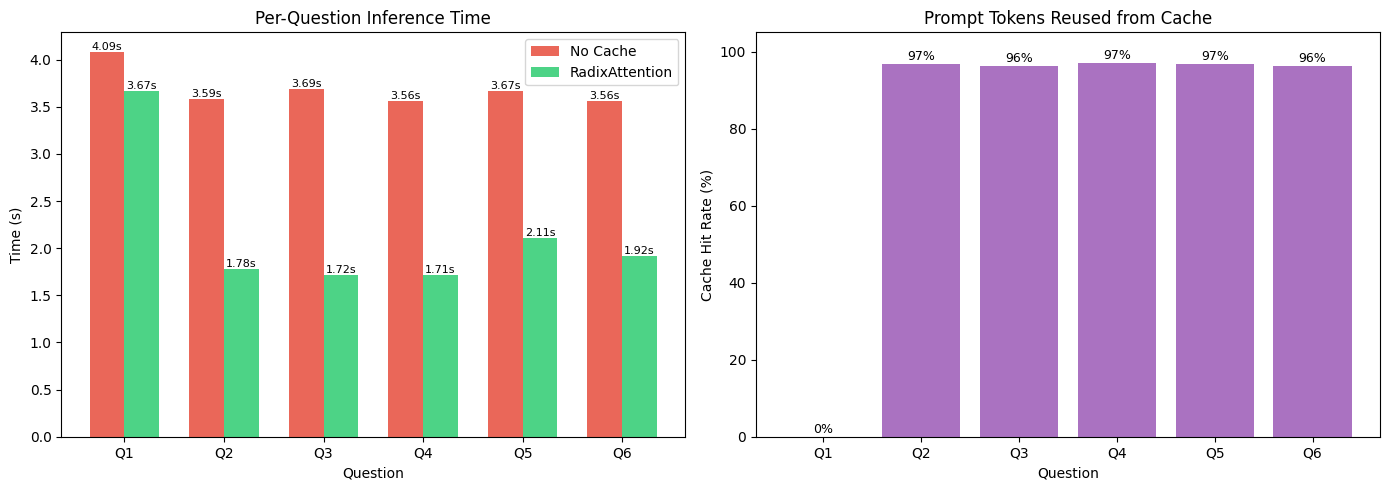

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(article0_questions))
w = 0.35
bars1 = ax1.bar(x - w/2, baseline_df['time'], w,label='No Cache', color='#e74c3c', alpha=0.85,)
bars2 = ax1.bar(x + w/2, radix_df['time'], w,label='RadixAttention', color='#2ecc71', alpha=0.85,)
ax1.set(xlabel='Question', ylabel='Time (s)',title='Per-Question Inference Time',)
ax1.set_xticks(x, [f'Q{i+1}' for i in x])
ax1.legend()
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., h,f'{h:.2f}s', ha='center',
            va='bottom', fontsize=8,)

prompt_lens = [
    len(tiny_llm.tokenize(
        construct_prompt(article0, q)
    ))
    for q in article0_questions
]
cache_rates = [
    (m / t * 100) if t > 0 else 0
    for m, t in zip(
        radix_df['cached_tokens'], prompt_lens
    )
]
ax2.bar(x, cache_rates, color='#9b59b6', alpha=0.85)
ax2.set(xlabel='Question',ylabel='Cache Hit Rate (%)',title='Prompt Tokens Reused from Cache',)
ax2.set_xticks(x, [f'Q{i+1}' for i in x])
ax2.set_ylim(0, 105)
for i, r in enumerate(cache_rates):
    ax2.text(i, r + 1, f'{r:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Experiment 3 — Mixed Article Workload

Real production traffic doesn't arrive grouped by document. Here, questions from **both articles** arrive in random order.

<div style="background-color: #f9f9f9; padding: 20px; border-radius: 5px; border: 1px solid #ddd; margin: 20px 0; font-family: sans-serif;">

<div style="display: flex; gap: 40px; align-items: flex-start;">

<!-- Left: mixed arrival order -->
<div style="flex: 1;">
<div style="font-weight: bold; font-size: 13px; margin-bottom: 12px;">Incoming requests (random order):</div>
<div style="display: flex; flex-direction: column; gap: 6px;">

<div style="display: flex; align-items: center; gap: 8px;">
  <div style="background-color: #ffcdd2; border: 1px solid #e57373; border-radius: 3px; padding: 4px 10px; font-size: 11px; color: #c62828; width: 100px; text-align: center;">Article 0, Q1</div>
  <div style="font-size: 12px; color: #999;">→</div>
  <div style="background-color: #fff5f5; border: 1px solid #e57373; border-radius: 3px; padding: 4px 10px; font-size: 11px; color: #c62828; flex: 1;"><b>MISS</b> — compute + store 😱💾</div>
</div>

<div style="display: flex; align-items: center; gap: 8px;">
  <div style="background-color: #bbdefb; border: 1px solid #64b5f6; border-radius: 3px; padding: 4px 10px; font-size: 11px; color: #1565c0; width: 100px; text-align: center;">Article 1, Q1</div>
  <div style="font-size: 12px; color: #999;">→</div>
  <div style="background-color: #fff5f5; border: 1px solid #e57373; border-radius: 3px; padding: 4px 10px; font-size: 11px; color: #c62828; flex: 1;"><b>MISS</b> — compute + store 😱💾</div>
</div>

<div style="display: flex; align-items: center; gap: 8px;">
  <div style="background-color: #ffcdd2; border: 1px solid #e57373; border-radius: 3px; padding: 4px 10px; font-size: 11px; color: #c62828; width: 100px; text-align: center;">Article 0, Q2</div>
  <div style="font-size: 12px; color: #999;">→</div>
  <div style="background-color: #f0f9f0; border: 1px solid #81c784; border-radius: 3px; padding: 4px 10px; font-size: 11px; color: #2e7d32; flex: 1;"><b>HIT</b> — Article 0 branch ✨</div>
</div>

<div style="display: flex; align-items: center; gap: 8px;">
  <div style="background-color: #bbdefb; border: 1px solid #64b5f6; border-radius: 3px; padding: 4px 10px; font-size: 11px; color: #1565c0; width: 100px; text-align: center;">Article 1, Q3</div>
  <div style="font-size: 12px; color: #999;">→</div>
  <div style="background-color: #f0f9f0; border: 1px solid #81c784; border-radius: 3px; padding: 4px 10px; font-size: 11px; color: #2e7d32; flex: 1;"><b>HIT</b> — Article 1 branch ✨</div>
</div>

<div style="display: flex; align-items: center; gap: 8px;">
  <div style="background-color: #ffcdd2; border: 1px solid #e57373; border-radius: 3px; padding: 4px 10px; font-size: 11px; color: #c62828; width: 100px; text-align: center;">Article 0, Q5</div>
  <div style="font-size: 12px; color: #999;">→</div>
  <div style="background-color: #f0f9f0; border: 1px solid #81c784; border-radius: 3px; padding: 4px 10px; font-size: 11px; color: #2e7d32; flex: 1;"><b>HIT</b> — Article 0 branch ✨</div>
</div>

<div style="display: flex; align-items: center; gap: 8px;">
  <div style="background-color: #bbdefb; border: 1px solid #64b5f6; border-radius: 3px; padding: 4px 10px; font-size: 11px; color: #1565c0; width: 100px; text-align: center;">Article 1, Q6</div>
  <div style="font-size: 12px; color: #999;">→</div>
  <div style="background-color: #f0f9f0; border: 1px solid #81c784; border-radius: 3px; padding: 4px 10px; font-size: 11px; color: #2e7d32; flex: 1;"><b>HIT</b> — Article 1 branch ✨</div>
</div>

</div>
</div>

<!-- Right: tree state -->
<div style="min-width: 220px;">
<div style="font-weight: bold; font-size: 13px; margin-bottom: 12px;">Tree state (after all requests):</div>

<div style="display: flex; align-items: center; gap: 8px; margin-bottom: 4px;">
  <div style="width: 14px; height: 14px; border-radius: 2px; background-color: #9e9e9e; flex-shrink: 0;"></div>
  <span style="font-size: 12px; color: #555;">[root]</span>
</div>

<div style="margin-left: 7px; border-left: 1.5px solid #bbb;">
  <div style="display: flex; align-items: center; gap: 8px; margin: 6px 0 4px 0;">
    <div style="width: 20px; height: 1.5px; background-color: #bbb; flex-shrink: 0;"></div>
    <div style="width: 14px; height: 14px; border-radius: 2px; background-color: #e57373; flex-shrink: 0;"></div>
    <div style="background-color: #ffcdd2; border: 1px solid #e57373; border-radius: 3px; padding: 3px 10px; font-size: 11px; color: #c62828;">Article 0 prefix 💾</div>
  </div>
  <div style="margin-left: 41px; border-left: 1.5px solid #bbb;">
    <div style="display: flex; align-items: center; gap: 8px; margin: 4px 0;">
      <div style="width: 20px; height: 1.5px; background-color: #bbb; flex-shrink: 0;"></div>
      <div style="width: 14px; height: 14px; border-radius: 2px; background-color: #ef9a9a; flex-shrink: 0;"></div>
      <div style="background-color: #ffebee; border: 1px solid #e57373; border-radius: 3px; padding: 3px 10px; font-size: 11px; color: #c62828;">Q1 … Q6</div>
    </div>
  </div>

  <div style="display: flex; align-items: center; gap: 8px; margin: 10px 0 4px 0;">
    <div style="width: 20px; height: 1.5px; background-color: #bbb; flex-shrink: 0;"></div>
    <div style="width: 14px; height: 14px; border-radius: 2px; background-color: #64b5f6; flex-shrink: 0;"></div>
    <div style="background-color: #bbdefb; border: 1px solid #64b5f6; border-radius: 3px; padding: 3px 10px; font-size: 11px; color: #1565c0;">Article 1 prefix 💾</div>
  </div>
  <div style="margin-left: 41px; border-left: 1.5px solid #bbb;">
    <div style="display: flex; align-items: center; gap: 8px; margin: 4px 0;">
      <div style="width: 20px; height: 1.5px; background-color: #bbb; flex-shrink: 0;"></div>
      <div style="width: 14px; height: 14px; border-radius: 2px; background-color: #90caf9; flex-shrink: 0;"></div>
      <div style="background-color: #e3f2fd; border: 1px solid #64b5f6; border-radius: 3px; padding: 3px 10px; font-size: 11px; color: #1565c0;">Q1 … Q6</div>
    </div>
  </div>
</div>
</div>

</div>

<div style="font-size: 12px; color: #666; margin-top: 16px; border-left: 4px solid #f9a825; padding: 10px; background-color: #fff9e6; border-radius: 3px;">
Two misses total — one per article, on first encounter. After that, every request hits its own branch regardless of arrival order. The tree never evicts one prefix when the other arrives.
</div>

</div>

Recall from the slides how the tree grows: when a request with a different prefix arrives, the tree branches — one branch per conversation, shared prefix stored only once. The tree holds both prefixes simultaneously. It's not a single-entry cache that gets blown away by the next request — each incoming request finds its own match independently.

In [18]:
# Minimum tokens to count as a meaningful prefix hit.
# Both prompts share "Article:\n" (~3 tokens) —
# that's not a real cache hit.
MIN_PREFIX_MATCH = 20

all_prompts = []
for q in article0_questions:
    all_prompts.append((
        "article0", "SGLang Serving",
        construct_prompt(article0, q),
    ))
for q in article1_questions:
    all_prompts.append((
        "article1", "KV Cache",
        construct_prompt(article1, q),
    ))

random.seed(42)
random.shuffle(all_prompts)

print(f"{len(all_prompts)} prompts from 2 articles, "
      f"shuffled randomly")

12 prompts from 2 articles, shuffled randomly


In [ ]:
print("Mixed Workload: Two Articles, Random Order")
print("=" * 55)

radix_multi = FlatRadixTree()
multi_results = []

for i, (tag, article_name, prompt) in enumerate(
    all_prompts
):
    token_ids = tiny_llm.tokenize(prompt)

    prefix_cache = radix_multi.search(token_ids)
    matched = (
        prefix_cache.get_seq_length(0)
        if prefix_cache is not None else 0
    )

    effective_cache = (
        prefix_cache
        if matched >= MIN_PREFIX_MATCH
        else None
    )

    tic = time.time()
    out, cached_req = (
        tiny_llm.generate_with_prefix_cache(
            prompt,
            max_new_tokens=max_new_tokens,
            stop_strs=["\n", "Answer:"],
            prefix_cache=effective_cache,
            temperature=0,
        )
    )
    elapsed = time.time() - tic

    radix_multi.insert(
        cached_req.token_ids,
        cached_req.kv_cache,
    )

    is_hit = matched >= MIN_PREFIX_MATCH
    multi_results.append({
        'request_num': i + 1,
        'article': tag,
        'article_name': article_name,
        'time': elapsed,
        'matched_tokens': (
            matched if is_hit else 0
        ),
    })

    status = (
        f"HIT ({matched})" if is_hit else "MISS"
    )
    print(
        f"  {i+1:2d}. [{article_name:14s}]"
        f" {elapsed:.3f}s  {status}"
    )

multi_df = pd.DataFrame(multi_results)
cache_hits = (
    multi_df['matched_tokens'] > 0
).sum()
hit_pct = cache_hits / len(multi_df) * 100
print(
    f"\nCache hits: {cache_hits}/{len(multi_df)}"
    f" ({hit_pct:.0f}%)"
)
print(
    f"Average time: "
    f"{multi_df['time'].mean():.3f}s"
)

Mixed Workload: Two Articles, Random Order
   1. [KV Cache      ] 4.141s  MISS
   2. [SGLang Serving] 3.675s  MISS
   3. [SGLang Serving] 1.704s  HIT (422)
   4. [KV Cache      ] 1.703s  HIT (491)
   5. [KV Cache      ] 1.725s  HIT (491)
   6. [KV Cache      ] 1.747s  HIT (493)


### Mixed Workload Visualization + Analysis

**Left:** Timeline — cold-start requests (first encounter of each article) show higher latency. Once both prefixes are in the tree, everything is fast.

**Right:** Overall hit rate — only 2 misses (one per article), everything else is a hit.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if a == 'article0' else '#3498db'for a in multi_df['article']]
ax1.scatter(multi_df['request_num'], multi_df['time'],c=colors, s=120, edgecolors='black', lw=1.5,)
ax1.set(xlabel='Request Number', ylabel='Time (s)',title='Request Timeline',)
ax1.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w',markerfacecolor='#e74c3c',
        markersize=10, label='SGLang Serving',markeredgecolor='black',),
    plt.Line2D([0], [0], marker='o', color='w',markerfacecolor='#3498db',
        markersize=10, label='KV Cache',markeredgecolor='black',),
])

cache_misses = len(multi_df) - cache_hits
ax2.pie([cache_hits, cache_misses],labels=[f'Hit ({cache_hits})',f'Miss ({cache_misses})',],
    autopct='%1.0f%%',colors=['#2ecc71', '#e74c3c'],wedgeprops=dict(edgecolor='black', lw=1.5),textprops=dict(fontweight='bold'),)
ax2.set_title('Cache Hit Rate')

plt.tight_layout()
plt.show()

In [ ]:
# Analyze mixed workload results
hits_df = multi_df[multi_df['matched_tokens'] > 0]
misses_df = multi_df[multi_df['matched_tokens'] == 0]

avg_hit_time = hits_df['time'].mean()
avg_miss_time = misses_df['time'].mean()
hit_vs_miss_speedup = avg_miss_time / avg_hit_time

# Per-article breakdown
print("Per-Article Breakdown")
print("=" * 55)
for article_name in ['SGLang Serving', 'KV Cache']:
    art_df = multi_df[
        multi_df['article_name'] == article_name
    ]
    art_hits = (art_df['matched_tokens'] > 0).sum()
    art_total = len(art_df)
    art_avg = art_df['time'].mean()
    print(
        f"  {article_name:16s}  "
        f"{art_hits}/{art_total} hits  "
        f"avg {art_avg:.3f}s"
    )

print(
    f"\nCache Miss (cold start):  "
    f"avg {avg_miss_time:.3f}s  "
    f"({len(misses_df)} requests)"
)
print(
    f"Cache Hit  (reuse):      "
    f"avg {avg_hit_time:.3f}s  "
    f"({len(hits_df)} requests)"
)
print(f"Hit vs Miss speedup:     {hit_vs_miss_speedup:.2f}x")
print(f"\nTotal requests:  {len(multi_df)}")
print(f"Total time:      {multi_df['time'].sum():.2f}s")
print(
    f"Amortized cost:  "
    f"{multi_df['time'].mean():.3f}s/request"
)
n_miss = len(misses_df)
n_total = len(multi_df)
print(
    f"\nKey insight: {n_miss} cold starts "
    f"amortized across {n_total} requests."
)
print(
    f"As traffic grows, the miss ratio -> 0 "
    f"and average time -> {avg_hit_time:.3f}s"
)

## 6. Summary

Side-by-side: Experiments 1 vs 2. First encounter = 1× (building the cache). Every subsequent question ≈ 2×. With longer documents the cached prefix is a larger fraction, and the speedup scales accordingly.

In [ ]:
comparison = pd.DataFrame({
    'Question': [f'Q{i+1}' for i in range(len(article0_questions))],
    'No Cache (s)': baseline_df['time'].values,
    'With Cache (s)': radix_df['time'].values,
    'Cached Tokens': radix_df['cached_tokens'].values,
    'Cache Rate (%)': cache_rates,
    'Speedup': baseline_df['time'].values / radix_df['time'].values,
})

print(comparison.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print(f"\nAverage speedup:    {comparison['Speedup'].mean():.2f}x")
print(f"Average cache rate: {comparison['Cache Rate (%)'].mean():.1f}%")
print(f"Total time saved:   {baseline_df['time'].sum() - radix_df['time'].sum():.1f}s")

## 7. Key Takeaways

Let's connect the three lessons. **L1:** autoregressive generation recomputes quadratically. **L2:** KV cache fixes that *within* a request — O(n²) → O(n), store Keys and Values, never recompute past tokens. **L3:** prefix caching extends it *across* requests — shared prefixes stored in a radix tree, computed once, reused by every matching request.

The code pattern is three lines: **search** the tree, **generate** with the cached prefix, **insert** the result.

| Use Case | What Gets Cached | Typical Speedup |
|----------|-----------------|----------------|
| RAG Systems | Document context | 5–10× |
| Chatbots | System prompt + history | 3–5× |
| Few-Shot Learning | Example demonstrations | 4–8× |
| Code Generation | Repository context | 3–6× |

**Next lesson** — we leave text behind for images. SGLang Diffusion: different pipeline, different model, different bottleneck. But caching reappears — instead of caching KV tensors across token positions, you cache noise predictions across denoising timesteps. Different domain, same instinct: if the computation hasn't changed, don't redo it.